### Skill Craft Technology Data Science Internship

#### Task 01: Visualize The Distribution of Population 

import Libraries

In [103]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot  as plt 


Load Dataset

In [104]:
df=pd.read_csv("/home/user/Downloads/population.csv",skiprows=4)


Dataset Preview

In [105]:
df.head()


,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,"Population, total",SP.POP.TOTL,54922.0,55578.0,56320.0,57002.0,57619.0,58190.0,...,108735.0,108908.0,109203.0,108587.0,107700.0,107310.0,107359.0,107995.0,NaN,NaN
1,Africa Eastern and Southern,AFE,"Population, total",SP.POP.TOTL,130075728.0,133534923.0,137171659.0,140945536.0,144904094.0,149033472.0,...,640058741.0,657801085.0,675950189.0,694446100.0,713090928.0,731821393.0,750491370.0,769280888.0,NaN,NaN
2,Afghanistan,AFG,"Population, total",SP.POP.TOTL,9035043.0,9214083.0,9404406.0,9604487.0,9814318.0,10036008.0,...,35688935.0,36743039.0,37856121.0,39068979.0,40000412.0,40578842.0,41454761.0,42647492.0,NaN,NaN
3,Africa Western and Central,AFW,"Population, total",SP.POP.TOTL,97630925.0,99706674.0,101854756.0,104089175.0,106388440.0,108772632.0,...,440882906.0,452195915.0,463365429.0,474569351.0,485920997.0,497387180.0,509398589.0,521764076.0,NaN,NaN
4,Angola,AGO,"Population, total",SP.POP.TOTL,5231654.0,5301583.0,5354310.0,5408320.0,5464187.0,5521981.0,...,30234839.0,31297155.0,32375632.0,33451132.0,34532429.0,35635029.0,36749906.0,37885849.0,NaN,NaN


Dataset Shape

In [106]:
print("shape :",df.shape)
print("Rows :",df.shape[0])
print("Columns :",df.shape[1])


shape : (266, 71)
Rows : 266
Columns : 71


Data Exploration

In [107]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 71 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    266 non-null    object 
 1   Country Code    266 non-null    object 
 2   Indicator Name  266 non-null    object 
 3   Indicator Code  266 non-null    object 
 4   1960            264 non-null    float64
 5   1961            264 non-null    float64
 6   1962            264 non-null    float64
 7   1963            264 non-null    float64
 8   1964            264 non-null    float64
 9   1965            264 non-null    float64
 10  1966            264 non-null    float64
 11  1967            264 non-null    float64
 12  1968            264 non-null    float64
 13  1969            264 non-null    float64
 14  1970            264 non-null    float64
 15  1971            264 non-null    float64
 16  1972            264 non-null    float64
 17  1973            264 non-null    flo

In [108]:
df.describe


<bound method NDFrame.describe of                     Country Name Country Code     Indicator Name  \
0                          Aruba          ABW  Population, total   
1    Africa Eastern and Southern          AFE  Population, total   
2                    Afghanistan          AFG  Population, total   
3     Africa Western and Central          AFW  Population, total   
4                         Angola          AGO  Population, total   
..                           ...          ...                ...   
261                       Kosovo          XKX  Population, total   
262                  Yemen, Rep.          YEM  Population, total   
263                 South Africa          ZAF  Population, total   
264                       Zambia          ZMB  Population, total   
265                     Zimbabwe          ZWE  Population, total   

    Indicator Code         1960         1961         1962         1963  \
0      SP.POP.TOTL      54922.0      55578.0      56320.0      57002.0   
1

Missing values

In [109]:
missing=df.isnull().sum()
missing[missing>0]


1960             2
1961             2
1962             2
1963             2
1964             2
              ... 
2022             1
2023             1
2024             1
2025           266
Unnamed: 70    266
Length: 67, dtype: int64

Remove unnecessary columns

In [110]:

df.drop(columns=['unnamed:70'],inplace=True,errors='ignore')


Remove missing values for the year 2022

In [119]:
df=df.dropna(subset=['2022'])


Remove Duplicate rows

In [118]:
df=df.drop_duplicates().copy()


Step 1: Define Population Ranges

In [113]:
bins=[0,
      1000000,
      10000000,
      50000000,
      100000000,
      500000000,
      2000000000]

label=[
'Below 1M',
'1M-10M',
'10M-50M',
'50M-100M',
'100M-500M',
'Above 500M'
]




Explanation

bins define the numerical boundaries, while labels provide readable names for each interval.

Step 2: Create a New Feature

In [117]:

df.loc[:,"Population Category"] = pd.cut(
    df["2022"],
    bins=bins,
    labels=labels)


Explanation

pd.cut() converts the continuous population values into categorical groups and stores the result in a new column named Population Category.

Step 3: Verify the New Feature

In [116]:
df[["Country Name", "2022", "Population Category"]].head(10)


,Country Name,2022,Population Category
0,Aruba,107310.0,Below 1M
1,Africa Eastern and Southern,731821393.0,Above 500M
2,Afghanistan,40578842.0,10M-50M
3,Africa Western and Central,497387180.0,100M-500M
4,Angola,35635029.0,10M-50M
5,Albania,2451636.0,1M-10M
6,Andorra,79705.0,Below 1M
7,Arab World,471352066.0,100M-500M
8,United Arab Emirates,10074977.0,10M-50M
9,Argentina,45407904.0,10M-50M


Step 4: Count Countries in Each Category

In [ ]:
population_group=(df["Population Category"].value_counts().sort_index())
print(population_group)


Population Category
Below 1M      57
1M-10M        68
10M-50M       67
50M-100M      14
100M-500M     21
Above 500M    26
Name: count, dtype: int64


#### Step 5: Visualize the Categories

A bar graph is used to compare the different categories of data using rectangular bars.Compare values across different categories.Identify the highest and lowest values.Visualize distributions of categorical variables clearly.


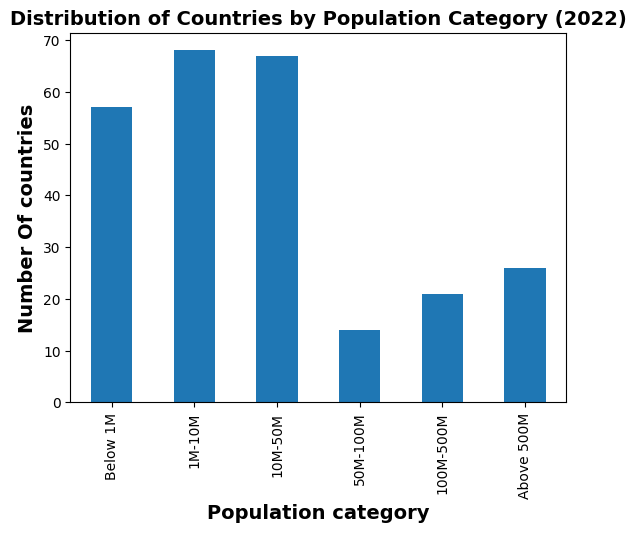

In [127]:
df['Population Category'].value_counts().sort_index().plot(
kind='bar')
plt.xlabel("Population category",fontsize=14,fontweight="bold")
plt.ylabel("Number Of countries",fontweight="bold",fontsize=14)
plt.title(
    "Distribution of Countries by Population Category (2022)",
    fontsize=14,
    fontweight="bold"
    
)
plt.savefig("Bargraph.png")
plt.show()



#### Conclusion

This task involved cleaning population data and visualizing population distribution using graphical techniques.By the end of this Task,real world Dataset is represented as barchat by categorizing countries into population ranges.

